In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import re

from IPython.display import display

In [2]:
def calculate_apdex(df, threshold=500):
    satisfied = (df['elapsed'] <= threshold).sum()
    tolerating = ((df['elapsed'] > threshold) & (df['elapsed'] <= 4 * threshold)).sum()
    total = len(df)
    return (satisfied + tolerating / 2) / total if total > 0 else 0.0

In [3]:
def process_file(file, apdex_threshold=500):
    df = pd.read_csv(file, sep=';', encoding='utf-8-sig', low_memory=False, dtype={'responseCode': str})
    df.columns = df.columns.str.strip().str.lower()

    df['success'] = df['success'].astype(str).str.lower() == 'true'

    total = len(df)
    success = df['success'].sum()
    error = total - success

    match = re.search(r'Baseline.*?(\d+)', file, re.IGNORECASE)
    users = int(match.group(1)) if match else None

    if not df.empty:
        start_time = df['timestamp'].min()
        end_time = df['timestamp'].max()
        duration_sec = (end_time - start_time) / 1000.0
        throughput = total / duration_sec if duration_sec > 0 else 0
    else:
        throughput = 0

    p90 = df['elapsed'].quantile(0.90) if not df.empty else 0
    p95 = df['elapsed'].quantile(0.95) if not df.empty else 0
    p99 = df['elapsed'].quantile(0.99) if not df.empty else 0

    apdex = calculate_apdex(df, threshold=apdex_threshold)

    return {
        'users': users,
        'total_requests': total,
        'success_rate (%)': round(success / total * 100, 2) if total > 0 else 0,
        'error_rate (%)': round(error / total * 100, 2) if total > 0 else 0,
        'avg_response (ms)': round(df['elapsed'].mean(), 2) if not df.empty else 0,
        'p90_response (ms)': round(p90, 2),
        'p95_response (ms)': round(p95, 2),
        'avg_latency (ms)': round(df['latency'].mean(), 2) if not df.empty else 0,
        'avg_connect (ms)': round(df['connect'].mean(), 2) if 'connect' in df.columns and not df.empty else 0,
        'throughput (req/s)': round(throughput, 2),
        'apdex': round(apdex, 3),
    }

In [4]:
def analyze_all(pattern="BaselineReport/Ghost Report - Baseline*.csv", apdex_threshold=500):
    files = glob.glob(pattern)
    if not files:
        print(f"Format file salah: {pattern}")
        return pd.DataFrame()

    results = []
    for f in sorted(files):
        results.append(process_file(f, apdex_threshold))

    df_result = pd.DataFrame(results)

    if df_result['users'].notna().all():
        df_result = df_result.sort_values(by='users').reset_index(drop=True)

    numeric_cols = df_result.select_dtypes(include='number').columns
    avg_values = df_result[numeric_cols].mean()

    avg_row = avg_values.to_dict()
    avg_row['users'] = 'Average'

    df_final = pd.concat([df_result, pd.DataFrame([avg_row])], ignore_index=True)

    cols = ['users'] + [col for col in df_final.columns if col != 'users']
    df_final = df_final[cols]

    return df_final

In [5]:
result = analyze_all("BaselineReport/Ghost Report - Baseline*.csv", apdex_threshold=500)
result.to_csv("Ghost Report - Baseline Summary.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=2)
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(result)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

users,total_requests,success_rate (%),error_rate (%),avg_response (ms),p90_response (ms),p95_response (ms),avg_latency (ms),avg_connect (ms),throughput (req/s),apdex
10,44933.00,100.00,0.00,127.48,176.00,207.00,120.29,0.33,74.89,1.00
20,49742.00,100.00,0.00,229.80,374.00,449.00,217.24,2.95,82.90,0.98
30,47605.00,99.99,0.01,359.90,646.00,785.00,340.80,2.28,79.34,0.90
40,46181.00,99.99,0.01,494.55,845.00,1026.00,465.44,2.01,76.97,0.81
50,48124.00,99.99,0.01,593.13,1227.00,1500.85,566.60,1.79,80.21,0.78
60,48587.00,99.98,0.02,717.21,1499.00,1858.00,670.63,8.04,80.98,0.74
70,47471.00,99.98,0.02,843.21,1924.00,2314.00,811.10,2.35,79.13,0.69
80,43703.00,99.94,0.06,1205.10,2032.00,2375.90,876.15,4.61,72.85,0.67
90,44475.00,99.99,0.01,1156.43,2920.00,3359.00,1134.58,3.16,74.13,0.60
100,44396.00,99.96,0.04,1286.51,2923.00,3556.00,1243.84,6.61,73.99,0.55


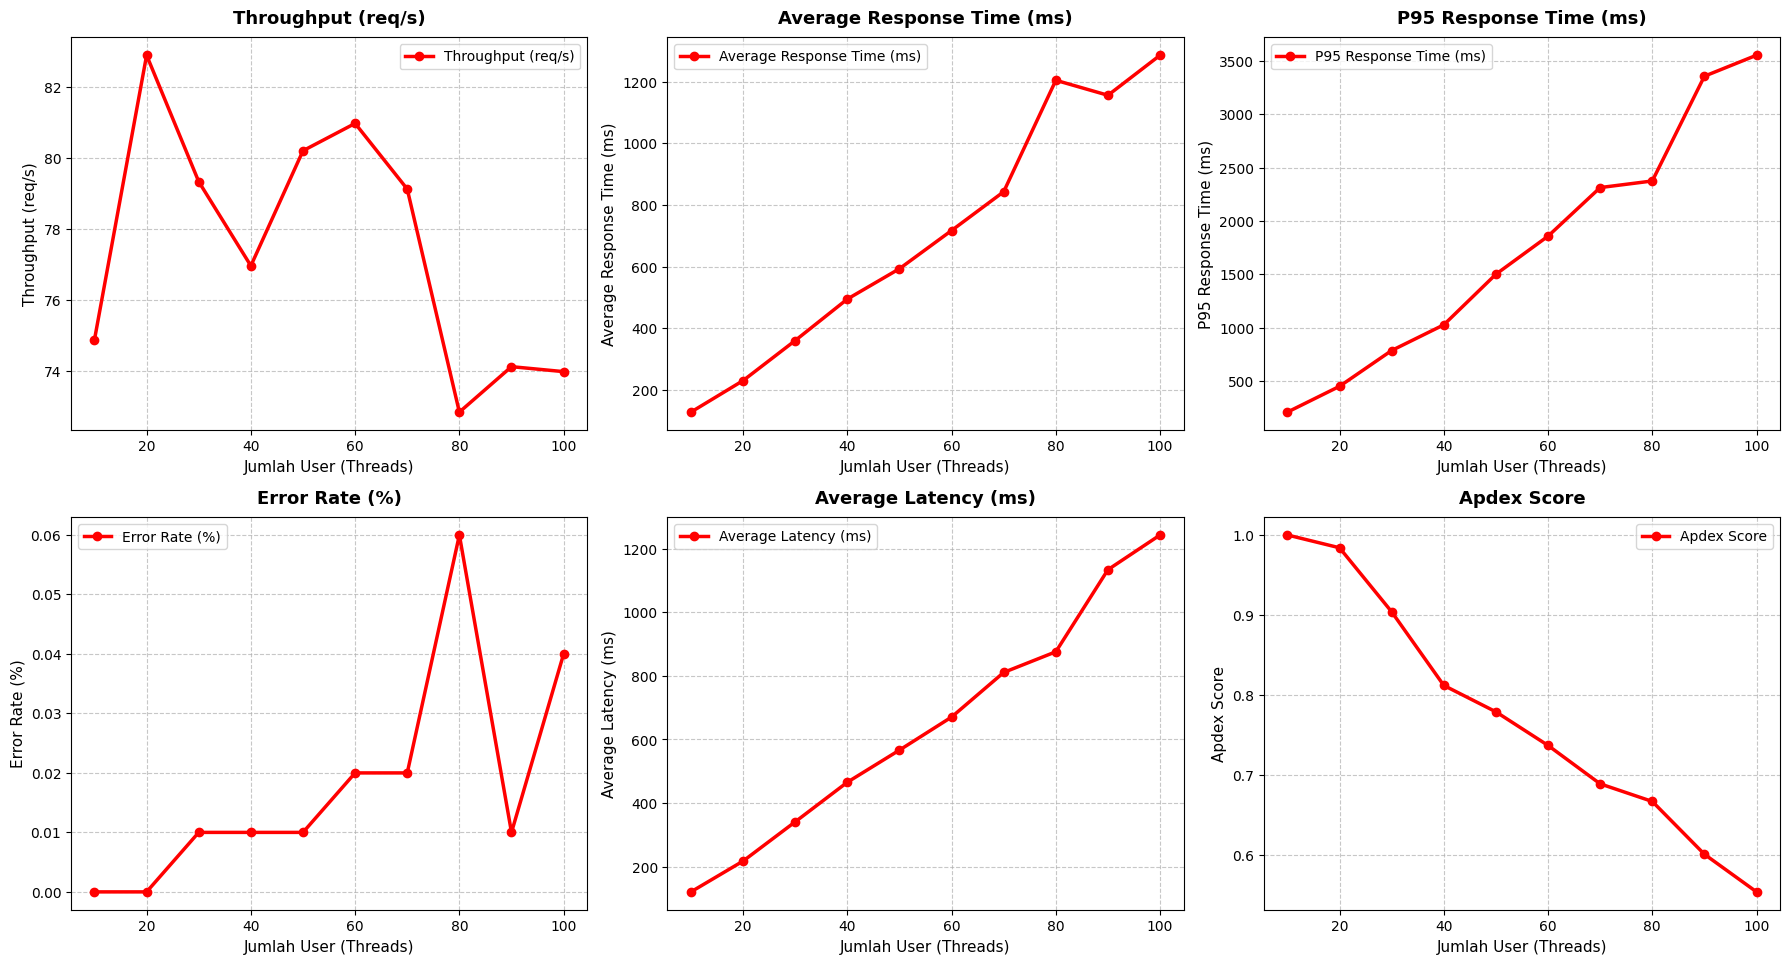

In [6]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

x = result['users'][:-1]

metrics = [
    ('throughput (req/s)',    'Throughput (req/s)',          'red'),
    ('avg_response (ms)',     'Average Response Time (ms)',  'red'),
    ('p95_response (ms)',     'P95 Response Time (ms)',      'red'),
    ('error_rate (%)',        'Error Rate (%)',              'red'),
    ('avg_latency (ms)',      'Average Latency (ms)',        'red'),
    ('apdex',                 'Apdex Score',                 'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 3)
    
    axs[row, col_idx].plot(x, result[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Ghost Report - Baseline.png")
plt.show()

In [7]:
def clean_cpu(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    value = float(match.group(1))
    if 'm' in val_str:
        return value
    else:
        return value * 1000

In [8]:
def clean_memory(val):
    if pd.isna(val):
        return 0
    val_str = str(val).strip().lower()
    match = re.search(r'(\d+\.?\d*)', val_str)
    if not match:
        return 0
    
    value = float(match.group(1))
    
    if 'gi' in val_str:
        return value * 1024
    elif 'mi' in val_str or 'mib' in val_str:
        return value
    elif 'ki' in val_str:
        return value / 1024
    else:
        return value

In [9]:
pattern = "BaselineResult/log_ghost-baseline_*-user.csv"
files = glob.glob(pattern)

results = []
for file in sorted(files):
    try:
        match = re.search(r'_(\d+)-user', file)
        user_count = int(match.group(1)) if match else 0
        
        df = pd.read_csv(file)
        
        df['CPU_cleaned'] = df['CPU_m'].apply(clean_cpu)
        df['Memory_cleaned'] = df['Memory_Mi'].apply(clean_memory)

        pods = df['Pod_Name'][df['Pod_Name'].str.startswith('ghost-deployment', na=False)]
        pod_count = pods.nunique()
        
        avg_cpu = df['CPU_cleaned'].mean()
        max_cpu = df['CPU_cleaned'].max()
        avg_mem = df['Memory_cleaned'].mean()
        max_mem = df['Memory_cleaned'].max()
        
        results.append({
            'Users': user_count,
            'Replicas': int(pod_count),
            'Avg CPU (m)': round(avg_cpu, 2),
            'Max CPU (m)': round(max_cpu, 2),
            'Avg Memory (Mi)': round(avg_mem, 2),
            'Max Memory (Mi)': round(max_mem, 2),
            'Samples': len(df)
        })
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='Users').reset_index(drop=True)

In [10]:
numeric_cols = ['Avg CPU (m)', 'Replicas', 'Max CPU (m)', 'Avg Memory (Mi)', 'Max Memory (Mi)', 'Samples']
avg_row = summary_df[numeric_cols].mean()
avg_row['Users'] = 'Average'

summary = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
summary.to_csv("Ghost Result - Baseline Summary.csv", index=False)

styled = (summary.style
          .hide(axis="index")
          .format(precision=2)
          .format(subset=['Replicas', 'Samples'], formatter="{:.0f}")
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(summary)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

Users,Replicas,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi),Samples
10,3,305.80,724.00,271.77,460.00,450
20,4,264.79,843.00,234.75,474.00,644
30,4,315.46,874.00,223.01,479.00,551
40,4,302.04,862.00,223.33,485.00,569
50,4,312.96,945.00,224.15,488.00,569
60,4,212.62,915.00,212.72,494.00,857
70,4,278.61,932.00,225.35,504.00,640
80,4,295.68,898.00,230.12,508.00,600
90,4,206.62,964.00,219.73,516.00,861
100,4,331.04,888.00,235.49,500.00,531


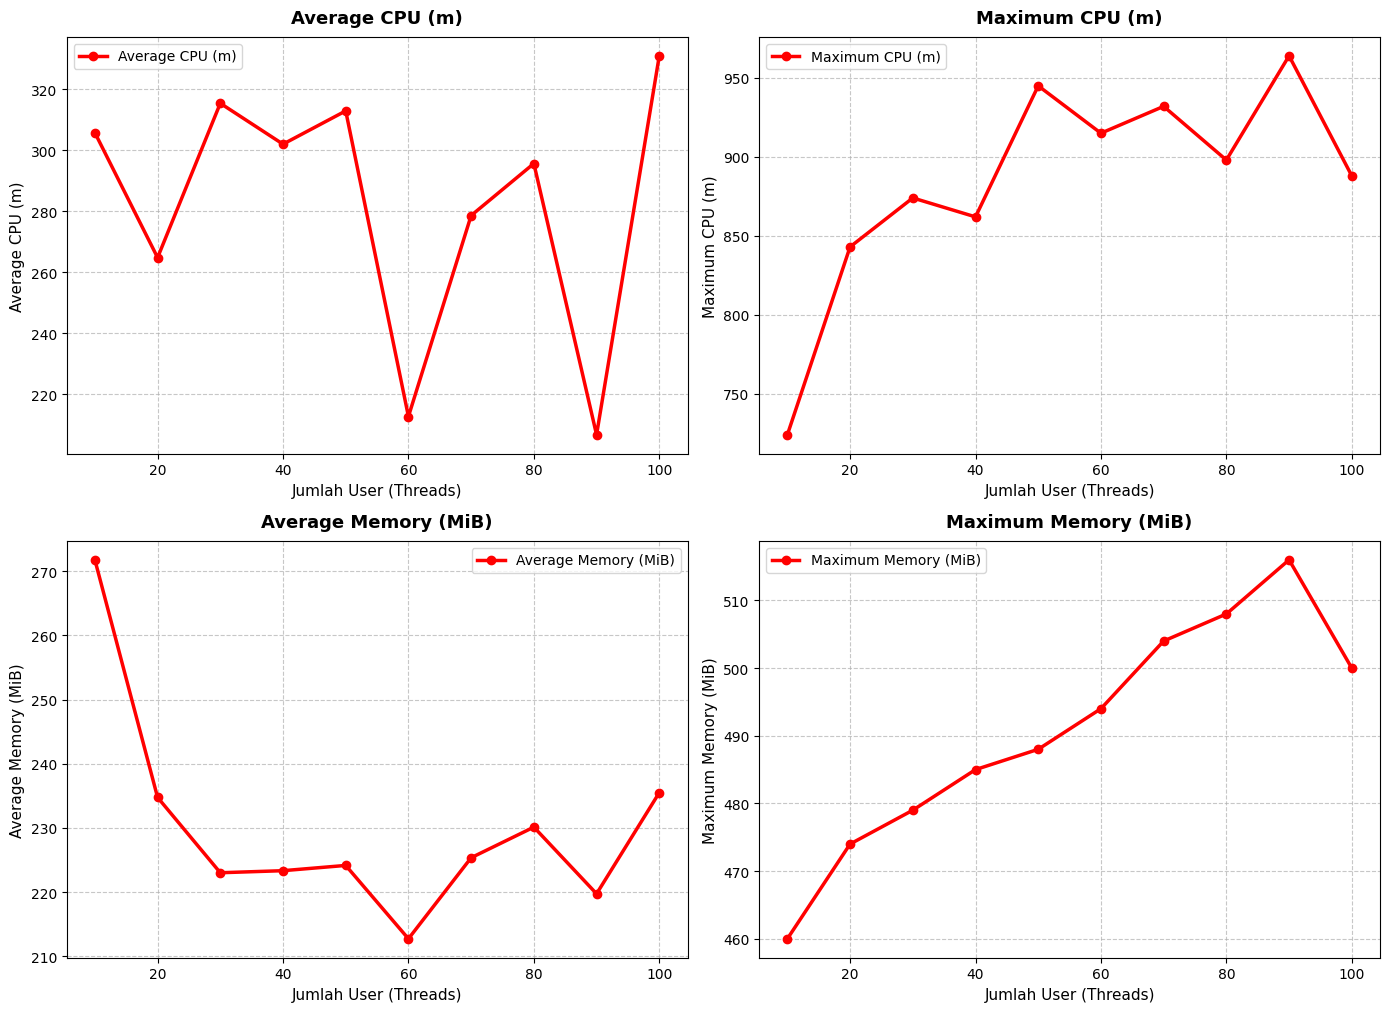

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

x = summary['Users'][:-1]

metrics = [
    ('Avg CPU (m)',     'Average CPU (m)',             'red'),
    ('Max CPU (m)',     'Maximum CPU (m)',             'red'),
    ('Avg Memory (Mi)', 'Average Memory (MiB)',        'red'),
    ('Max Memory (Mi)', 'Maximum Memory (MiB)',        'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 2)
    
    axs[row, col_idx].plot(x, summary[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("Ghost Result - Baseline.png")
plt.show()

In [12]:
pattern = "BaselineKernel/log-kernel-monitoring_ghost-baseline*-user.csv"
files = glob.glob(pattern)

results = []
for file in sorted(files):
    try:
        match = re.search(r'_(\d+)-user', file)
        user_count = int(match.group(1)) if match else 0
        
        df = pd.read_csv(file)
        
        df['CPU_Total'] = df['CPU_User'] + df['CPU_System']
        df['Memory_Total'] = df['Mem_Free_MB'] + df['Mem_Cache_MB']
        df['IO_Total'] = df['IO_Read_S'] + df['IO_Write_S']

        avg_cpu = df['CPU_Total'].mean()
        max_cpu = df['CPU_Total'].max()

        avg_mem = df['Memory_Total'].mean()
        max_mem = df['Memory_Total'].max()

        avg_io = df['IO_Total'].mean()
        max_io = df['IO_Total'].max()

        context_switches = df['Context_Switches'].mean()
        
        results.append({
            'Users': user_count,
            'Avg CPU (%)': round(avg_cpu, 2),
            'Max CPU (%)': round(max_cpu, 2),
            'Avg Memory (MB)': round(avg_mem, 2),
            'Max Memory (MB)': round(max_mem, 2),
            'Avg I/O (S)': round(avg_io, 2),
            'Max I/O (S)': round(max_io, 2),
            'Context Switches': round(context_switches, 2),
            'Samples': len(df),
        })
        
    except Exception as e:
        print(f"Error processing {file}: {e}")

summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='Users').reset_index(drop=True)

In [13]:
numeric_cols = ['Avg CPU (%)', 'Max CPU (%)', 'Avg Memory (MB)', 'Max Memory (MB)', 'Avg I/O (S)', 'Max I/O (S)', 'Context Switches', 'Samples']
avg_row = summary_df[numeric_cols].mean()
avg_row['Users'] = 'Average'

summary = pd.concat([summary_df, pd.DataFrame([avg_row])], ignore_index=True)
summary.to_csv("Ghost Kernel - Baseline Summary.csv", index=False)

styled = (summary.style
          .hide(axis="index")
          .format(precision=2)
          .format(subset=['Context Switches', 'Samples'], formatter="{:.0f}")
          .apply(lambda row: ['font-weight: bold' 
                              if row.name == len(summary)-1 else '' 
                              for _ in row], axis=1)
         )

display(styled)

Users,Avg CPU (%),Max CPU (%),Avg Memory (MB),Max Memory (MB),Avg I/O (S),Max I/O (S),Context Switches,Samples
10,74.26,97.00,4027.16,4308.00,615.37,5552.00,19684,89
20,76.89,100.00,3903.61,4318.00,466.74,3288.00,19776,104
30,88.42,100.00,3868.11,4286.00,566.08,7296.00,20670,89
40,83.87,101.00,3857.71,4280.00,619.82,7776.00,20466,91
50,90.62,100.00,3814.40,4278.00,634.03,6516.00,20813,89
60,65.88,101.00,3862.24,4275.00,568.75,9896.00,18873,132
70,85.32,101.00,3867.49,4259.00,742.84,10228.00,20518,95
80,55.99,101.00,4071.88,4517.00,760.60,14320.00,18002,158
90,62.00,101.00,3994.74,4379.00,786.25,11988.00,18694,142
100,88.33,100.00,3958.92,4345.00,876.78,9612.00,20722,91


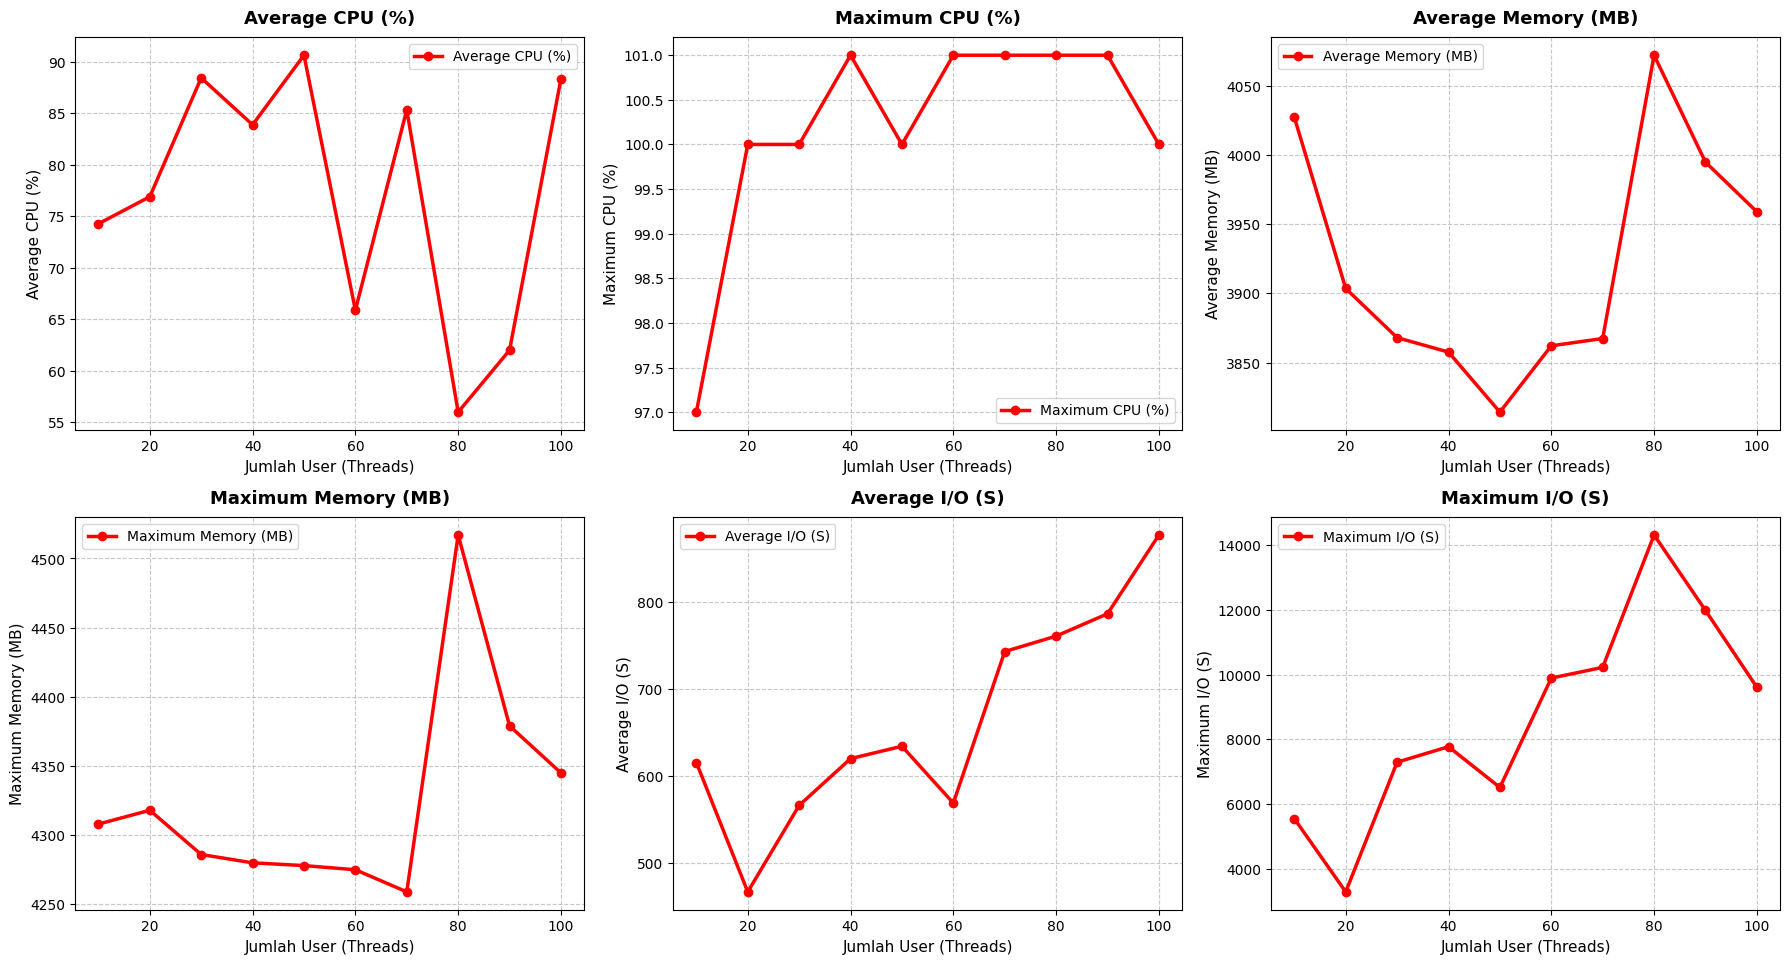

In [14]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

x = summary['Users'][:-1]

metrics = [
    ('Avg CPU (%)',     'Average CPU (%)',            'red'),
    ('Max CPU (%)',     'Maximum CPU (%)',            'red'),
    ('Avg Memory (MB)', 'Average Memory (MB)',        'red'),
    ('Max Memory (MB)', 'Maximum Memory (MB)',        'red'),
    ('Avg I/O (S)',     'Average I/O (S)',            'red'), 
    ('Max I/O (S)',     'Maximum I/O (S)',            'red'),
]

for i, (col, title, color) in enumerate(metrics):
    row, col_idx = divmod(i, 3)
    
    axs[row, col_idx].plot(x, summary[col][:-1], 
                           marker='o', linewidth=2.5, color=color, label=title)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Jumlah User (Threads)", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)
    axs[row, col_idx].legend(fontsize=10)

for j in range(6, 9):
    axs.flat[j].set_visible(False)
    
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Ghost Kernel - Baseline.png")
plt.show()